In [2]:
from google.colab import files
uploaded = files.upload()

Saving Twitter_Data.csv.zip to Twitter_Data.csv.zip


In [4]:
import zipfile

with zipfile.ZipFile('Twitter_Data.csv.zip', 'r') as zip_ref:
    zip_ref.extractall()

print("Extracted successfully")

Extracted successfully


In [5]:
import os
print(os.listdir())

['.config', 'Twitter_Data.csv.zip', 'Twitter_Data.csv', 'sample_data']


In [6]:
import pandas as pd

df = pd.read_csv('Twitter_Data.csv')

df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [7]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSentiment Counts:")
print(df['category'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB
None

Missing Values:
clean_text    4
category      7
dtype: int64

Sentiment Counts:
category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64


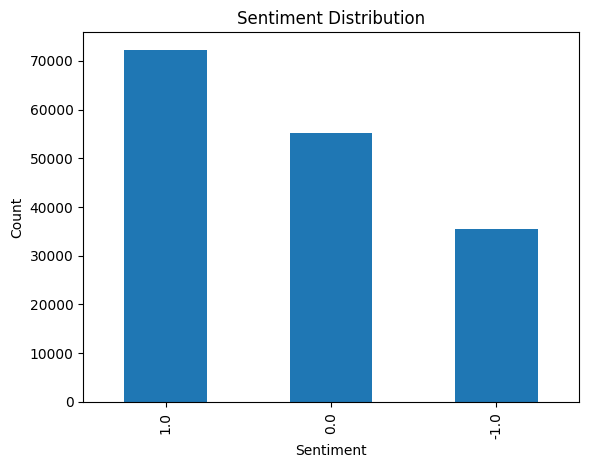

In [8]:
import matplotlib.pyplot as plt

df['category'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'].astype(str))

y = df['category']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [13]:

df = df.dropna(subset=['clean_text', 'category'])


df['category'] = df['category'].astype(int)

print(df.isnull().sum())

clean_text    0
category      0
dtype: int64


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'].astype(str))
y = df['category']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [17]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7374363379763147


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.91      0.42      0.57      7152
           0       0.88      0.67      0.76     11067
           1       0.65      0.95      0.78     14375

    accuracy                           0.74     32594
   macro avg       0.81      0.68      0.70     32594
weighted avg       0.79      0.74      0.72     32594



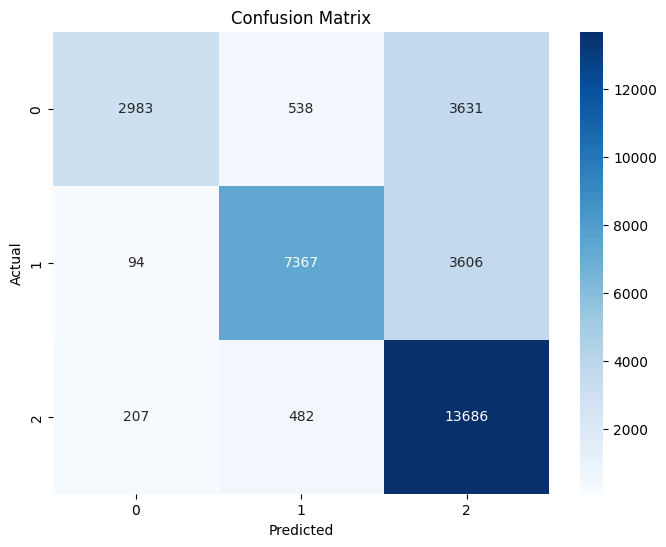

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()